In [1]:
import json

import duckdb
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from lending_pd.config import (CATEGORICAL_FEATURES, DB_PATH, MODEL_A_FEATURES, MODEL_B_EXTRA, ROOT)
from lending_pd.train import (add_state_grp, load_engineered, temporal_split, to_categorical)

FIG = ROOT / "reports" / "figures"

metrics = json.loads((ROOT / "reports" / "metrics.json").read_text())

models = {name: joblib.load(ROOT / "models" / f"{name}.joblib") for name in ["logistic_A", "logistic_B", "lgbm_A", "lgbm_B"]}

df = load_engineered()
train, test = temporal_split(df)
train, test = add_state_grp(train, test)
y_te = test["default_flag"]

In [2]:
def model_columns(features, categorical):
    numeric = [f for f in features if f not in categorical]
    return numeric + categorical

cols_A = model_columns(MODEL_A_FEATURES, CATEGORICAL_FEATURES)
cols_B = model_columns(MODEL_A_FEATURES + MODEL_B_EXTRA,
                       CATEGORICAL_FEATURES + ["sub_grade"])

_, test_A = to_categorical(train[cols_A], test[cols_A], CATEGORICAL_FEATURES)
_, test_B = to_categorical(train[cols_B], test[cols_B], CATEGORICAL_FEATURES + ["sub_grade"])

preds = {
    "logistic_A": models["logistic_A"].predict_proba(test_A)[:, 1],
    "logistic_B": models["logistic_B"].predict_proba(test_B)[:, 1],
    "lgbm_A": models["lgbm_A"].predict_proba(test_A)[:, 1],
    "lgbm_B": models["lgbm_B"].predict_proba(test_B)[:, 1],
}

assert abs(preds["lgbm_A"].mean() - 0.1310) < 0.0005
assert abs(preds["logistic_A"].mean() - 0.1347) <0.0005

In [3]:
test = test.copy()
test["realised_return"] = (
    (test["total_pymnt"] - test["collection_recovery_fee"])
    / test["loan_amnt"] - 1
)

In [4]:
test["realised_return"].describe()

count    194357.000000
mean          0.065860
std           0.224716
min          -1.000000
25%           0.071517
50%           0.122604
75%           0.181982
max           0.540997
Name: realised_return, dtype: float64

Above sanity check looks good with max=0.54 within expectd range.

grade      n  mean_rate  default_pct  mean_return_pct  sd_return_pct
    A 111485       7.29          5.5             7.14          12.53
    B 170216      11.03         11.1             9.07          18.80
    C 132603      14.09         17.7             8.72          24.88
    D  64215      17.35         23.0             8.82          30.07
    E  18267      20.10         28.1             7.97          34.58
    F   3664      23.95         32.3             8.76          39.36
    G    369      26.01         35.8             6.64          42.24


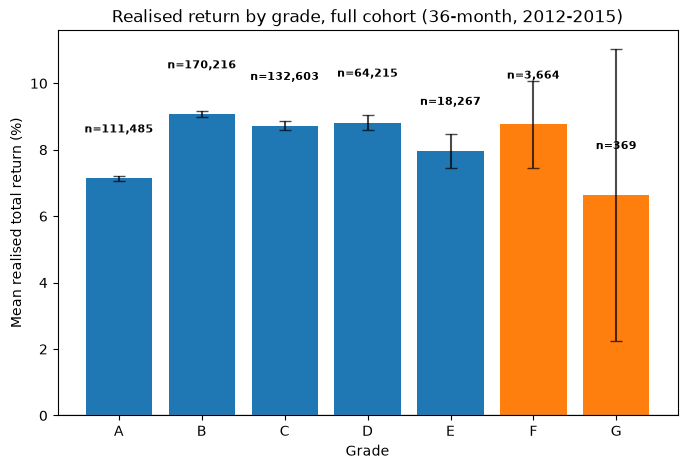

In [5]:
q_grade = """
SELECT grade,
        count(*) AS n,
        round(avg(int_rate), 2) AS mean_rate,
        round(avg(default_flag)*100, 1) AS default_pct,
        round(avg((total_pymnt - collection_recovery_fee)/loan_amnt - 1)*100, 2) AS mean_return_pct,
        round(stddev((total_pymnt - collection_recovery_fee)/loan_amnt - 1)*100, 2) AS sd_return_pct
FROM cohort
GROUP BY grade 
ORDER BY grade;
"""
import numpy as np
con = duckdb.connect(str(DB_PATH), read_only=True)
by_grade = con.execute(q_grade).df()
con.close()
print(by_grade.to_string(index=False))

fig, ax = plt.subplots(figsize= (8, 5))
se = by_grade["sd_return_pct"] / np.sqrt(by_grade["n"])
bars = ax.bar(by_grade["grade"], by_grade["mean_return_pct"],
              yerr=2*se, capsize=4, color=["C0"]*5 + ["C1"]*2, error_kw={"alpha":0.7})
ax.axhline(0, color="grey", lw=1)
for bar, n in zip(bars, by_grade["n"]):
    ax.annotate(f"n={n:,}", (bar.get_x() + bar.get_width()/2, bar.get_height() + 2*se.iloc[5]),
                ha="center", va="bottom", fontsize=8, weight="bold")
ax.set_xlabel("Grade")
ax.set_ylabel("Mean realised total return (%)")
ax.set_title("Realised return by grade, full cohort (36-month, 2012-2015)")
fig.savefig(FIG / "realised_return_by_grade.png", dpi=150, bbox_inches = "tight")
plt.show()


Realised returns peak at grade B (9.07%) and are statistically flat through F: the A -> B rate premium out-earned its extra defaults, but every step beyond B was fully consumed by them. The incremental risk was uncompensated in means and negatively compensated after adjusting for the tail's higher variance. The one precisely-measured deterioration is D -> E (−0.85pts, n=18k); F's apparent recovery and G's collapse sit inside sampling error (n=3,664 and 369; orange bars). Consistent with the rate-ceiling finding: pricing tracked risk through the middle of the book and stopped compensating it at the tail.

G's interval spans the full range of the chart; nothing about G can be concluded from 369 loans.